# Multiple Linear Regression – Multi-Channel Marketing Analysis

## Project Objective

This project investigates the relationship between marketing expenditure across multiple channels (TV, Radio, and Social Media) and Sales performance using Multiple Linear Regression.

The objectives are to:

- Explore and clean the dataset
- Examine relationships between variables
- Detect multicollinearity using correlation analysis and VIF
- Build a Multiple Linear Regression model using statsmodels
- Evaluate model performance using Adjusted R-squared and p-values
- Validate regression assumptions through diagnostic plots
- Provide business recommendations based on statistical findings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy import stats

%matplotlib inline

## Load Dataset

In [2]:
df = pd.read_csv("marketing.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (4572, 4)


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [4]:
df.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

## Data Cleaning and Missing Value Handling

The dataset contains missing values in the predictor variables and target variable. To ensure reliable model estimation, rows containing missing values are removed before analysis.

In [5]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Remove rows with missing values
df = df.dropna()

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDataset Shape After Cleaning:")
print(df.shape)

Missing values before cleaning:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

Missing values after cleaning:
TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

Dataset Shape After Cleaning:
(4546, 4)


## Exploratory Data Analysis (EDA)

Exploratory analysis is performed to understand the distribution of variables and identify relationships between marketing channels and Sales.

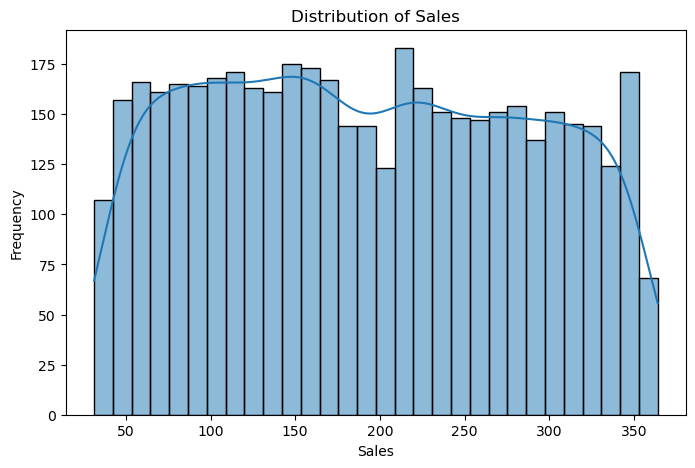

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

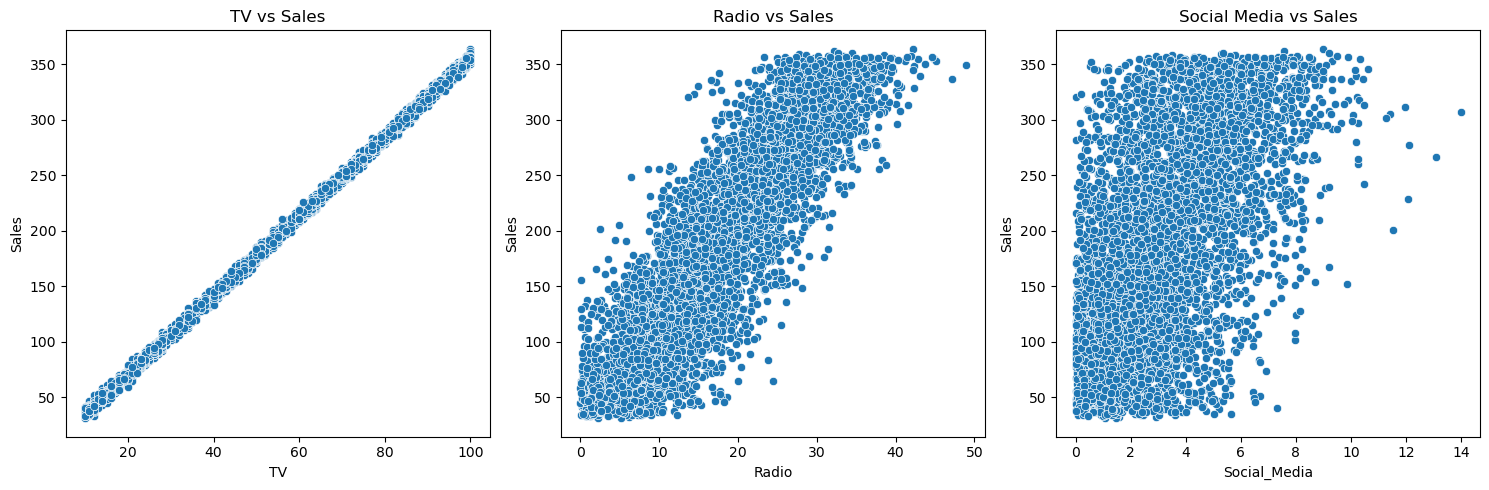

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.scatterplot(data=df, x='TV', y='Sales', ax=axes[0])
axes[0].set_title('TV vs Sales')

sns.scatterplot(data=df, x='Radio', y='Sales', ax=axes[1])
axes[1].set_title('Radio vs Sales')

sns.scatterplot(data=df, x='Social_Media', y='Sales', ax=axes[2])
axes[2].set_title('Social Media vs Sales')

plt.tight_layout()
plt.show()

## Correlation Analysis

A correlation matrix is used to evaluate relationships between marketing channels and Sales and to identify potential multicollinearity among predictors.

In [8]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,TV,Radio,Social_Media,Sales
TV,1.000000,0.869158,0.527687,0.999497
Radio,0.869158,1.000000,0.606338,0.868638
Social_Media,0.527687,0.606338,1.000000,0.527446
Sales,0.999497,0.868638,0.527446,1.000000


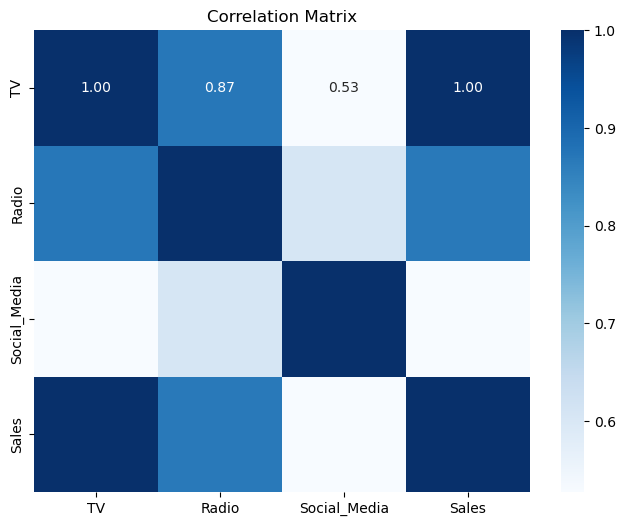

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

## Variance Inflation Factor (VIF)

Variance Inflation Factor (VIF) is used to detect multicollinearity among independent variables.

General guidelines:

- VIF < 5 : Acceptable
- VIF > 5 : Moderate multicollinearity
- VIF > 10 : Serious multicollinearity

In [10]:
X = df[['TV', 'Radio', 'Social_Media']]

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Variable,VIF
0,TV,18.565521
1,Radio,21.142069
2,Social_Media,4.960585


## Multiple Linear Regression Model

A Multiple Linear Regression model is developed to predict Sales using TV, Radio, and Social Media advertising expenditures.

In [11]:
X = df[['TV', 'Radio', 'Social_Media']]
y = df['Sales']

# Add intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.505e+06
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:54:01   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4542   BIC:                         2.277e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.1340      0.103     -1.303   

## Model Performance Evaluation

The model is evaluated using:

- Adjusted R-squared
- Predictor coefficients
- p-values
- Overall model significance

In [12]:
print("R-squared:", model.rsquared)
print("Adjusted R-squared:", model.rsquared_adj)
print("F-statistic p-value:", model.f_pvalue)

R-squared: 0.9989950217942258
Adjusted R-squared: 0.9989943580041295
F-statistic p-value: 0.0


## Interpretation of Regression Coefficients

The Multiple Linear Regression model indicates that TV advertising is the strongest predictor of Sales.

Holding Radio and Social Media expenditure constant, a one-unit increase in TV advertising expenditure is associated with an estimated 3.56-unit increase in Sales.

Radio and Social Media advertising expenditures are not statistically significant predictors in the presence of TV advertising expenditure, as their p-values exceed the 0.05 significance threshold.

The high VIF values for TV and Radio suggest multicollinearity, which may contribute to the reduced statistical significance of some predictors.

## Regression Assumption Diagnostics

Diagnostic plots are used to evaluate:

- Linearity
- Normality of residuals
- Homoscedasticity

In [13]:
df['Predicted_Sales'] = model.predict(X)

residuals = y - df['Predicted_Sales']

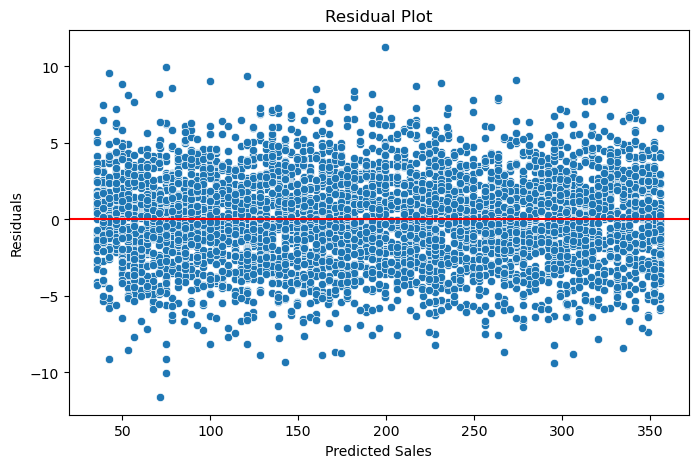

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Predicted_Sales'],
    y=residuals
)

plt.axhline(0, color='red')

plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.show()

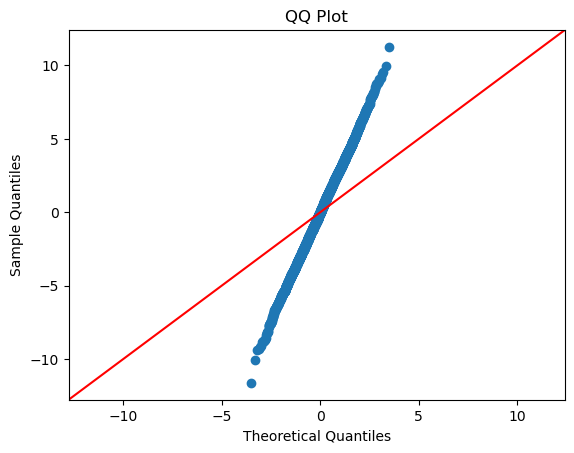

In [15]:
sm.qqplot(residuals, line='45')

plt.title("QQ Plot")

plt.show()

## Regression Assumption Assessment

| Assumption | Assessment | Evidence |
|------------|------------|-----------|
| Linearity | Satisfied | Residuals randomly scattered around zero |
| Normality | Satisfied | Q-Q plot approximately follows reference line |
| Homoscedasticity | Satisfied | Residual spread remains approximately constant |
| Independence | Satisfied | Durbin-Watson = 1.998 |

## Business Recommendation

The Multiple Linear Regression analysis identified TV advertising as the strongest and most statistically significant predictor of Sales.

Although Radio and Social Media advertising exhibit positive correlations with Sales individually, they are not statistically significant within the multiple regression model after accounting for TV advertising expenditure.

Variance Inflation Factor (VIF) analysis revealed substantial multicollinearity between TV and Radio advertising, which may reduce the statistical significance of some predictors.

Given the model results, future marketing investments should prioritize TV advertising, as it provides the largest measurable impact on Sales performance while remaining highly statistically significant.

## Final Conclusion

This project developed a Multiple Linear Regression model to examine the impact of TV, Radio, and Social Media advertising expenditures on Sales.

Key findings include:

- Missing values were successfully identified and removed.
- TV advertising exhibited the strongest correlation with Sales (0.9995).
- Significant multicollinearity was detected between TV and Radio advertising using VIF analysis.
- The regression model achieved an Adjusted R-squared of 0.999, indicating excellent predictive performance.
- TV advertising was the only statistically significant predictor (p < 0.001).
- Radio and Social Media advertising were not statistically significant after controlling for other variables.

### Regression Equation

Sales = -0.1340 + (3.5626 × TV) - (0.0040 × Radio) + (0.0050 × Social_Media)

### Stakeholder Interpretation

Holding Radio and Social Media spending constant, each additional unit of TV advertising expenditure is associated with an estimated 3.56-unit increase in Sales.

Overall, the analysis demonstrates that TV advertising provides the strongest return on investment and should receive the highest budget allocation in future campaigns.